In [1]:
# Check if pybaseball is installed
try:
    import pybaseball
    print("pybaseball successfully imported!")
except ImportError:
    print("pybaseball not found - installing now...")
    !pip install pybaseball
    import pybaseball
    print("pybaseball now installed!")

pybaseball not found - installing now...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 4.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 15.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.9/349.9 kB 27.5 MB/s eta 0:00:00
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
pybaseball now installed!


In [2]:
# Import all necessary libraries
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup
from datetime import datetime, timedelta
import pickle
import os
import time
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

# API Keys
OPENWEATHERMAP_API_KEY = "c9fc686d86d6a22e96844fa975d96f39"
ODDS_API_KEY = "d069cac732787dff5f9e9f476521cbe9"

# Enable inline plotting
%matplotlib inline

In [25]:
class MLBWeatherModel:
    def __init__(self, data_dir='data'):
        """Initialize the MLB Weather Model."""
        self.data_dir = data_dir
        self.games_df = None
        self.weather_df = None
        self.odds_df = None
        self.merged_data = None
        self.model = None
        
        # Create data directory if it doesn't exist
        if not os.path.exists(data_dir):
            os.makedirs(data_dir)
    
    def fetch_game_data(self, start_year, end_year):
        """
        Fetch real MLB game data using pybaseball with fixed date parsing.

        Parameters:
            start_year (int): First season to collect
            end_year (int): Last season to collect
        """
        print(f"Fetching MLB game data from {start_year} to {end_year}...")

        try:
            import pybaseball
            # Set the cache directory for pybaseball
            pybaseball.cache.enable()
        except ImportError:
            print("pybaseball not installed. Installing now...")
            !pip install pybaseball
            import pybaseball

        # Initialize empty DataFrame to store all games
        all_games = pd.DataFrame()

        # MLB teams - using abbreviations that match pybaseball
        teams = ['ARI', 'ATL', 'BAL', 'BOS', 'CHC', 'CHW', 'CIN', 'CLE', 
                 'COL', 'DET', 'HOU', 'KCR', 'LAA', 'LAD', 'MIA', 'MIL', 
                 'MIN', 'NYM', 'NYY', 'OAK', 'PHI', 'PIT', 'SDP', 'SEA', 
                 'SFG', 'STL', 'TBR', 'TEX', 'TOR', 'WSN']

        # Define stadium mapping
        stadium_mapping = {
            'LAA': {'name': 'Angel Stadium', 'lat': 33.8003, 'lon': -117.8827},
            'STL': {'name': 'Busch Stadium', 'lat': 38.6226, 'lon': -90.1928},
            'ARI': {'name': 'Chase Field', 'lat': 33.4452, 'lon': -112.0667},
            'NYM': {'name': 'Citi Field', 'lat': 40.7571, 'lon': -73.8458},
            'PHI': {'name': 'Citizens Bank Park', 'lat': 39.9061, 'lon': -75.1665},
            'DET': {'name': 'Comerica Park', 'lat': 42.339, 'lon': -83.0485},
            'COL': {'name': 'Coors Field', 'lat': 39.7559, 'lon': -104.9942},
            'LAD': {'name': 'Dodger Stadium', 'lat': 34.0739, 'lon': -118.24},
            'BOS': {'name': 'Fenway Park', 'lat': 42.3467, 'lon': -71.0972},
            'TEX': {'name': 'Globe Life Field', 'lat': 32.7515, 'lon': -97.0829},
            'CIN': {'name': 'Great American Ball Park', 'lat': 39.0979, 'lon': -84.5067},
            'CHW': {'name': 'Guaranteed Rate Field', 'lat': 41.83, 'lon': -87.6339},
            'KCR': {'name': 'Kauffman Stadium', 'lat': 39.0517, 'lon': -94.4803},
            'MIA': {'name': 'LoanDepot Park', 'lat': 25.7778, 'lon': -80.2197},
            'HOU': {'name': 'Minute Maid Park', 'lat': 29.7573, 'lon': -95.3555},
            'WSN': {'name': 'Nationals Park', 'lat': 38.873, 'lon': -77.0074},
            'OAK': {'name': 'Oakland Coliseum', 'lat': 37.7516, 'lon': -122.2005},
            'SFG': {'name': 'Oracle Park', 'lat': 37.7786, 'lon': -122.3893},
            'BAL': {'name': 'Oriole Park at Camden Yards', 'lat': 39.2838, 'lon': -76.6215},
            'SDP': {'name': 'Petco Park', 'lat': 32.7076, 'lon': -117.1569},
            'PIT': {'name': 'PNC Park', 'lat': 40.4469, 'lon': -80.0057},
            'CLE': {'name': 'Progressive Field', 'lat': 41.4962, 'lon': -81.6852},
            'TOR': {'name': 'Rogers Centre', 'lat': 43.6414, 'lon': -79.3894},
            'SEA': {'name': 'T-Mobile Park', 'lat': 47.5914, 'lon': -122.3425},
            'MIN': {'name': 'Target Field', 'lat': 44.9818, 'lon': -93.2775},
            'TBR': {'name': 'Tropicana Field', 'lat': 27.7682, 'lon': -82.6534},
            'ATL': {'name': 'Truist Park', 'lat': 33.8911, 'lon': -84.468},
            'CHC': {'name': 'Wrigley Field', 'lat': 41.9484, 'lon': -87.6553},
            'NYY': {'name': 'Yankee Stadium', 'lat': 40.8296, 'lon': -73.9262},
            'MIL': {'name': 'American Family Field', 'lat': 43.0280, 'lon': -87.9712},
        }

        # Store stadium mapping for later use
        self.stadium_mapping = stadium_mapping

        for year in range(start_year, end_year + 1):
            print(f"Processing {year} season...")

            try:
                # Use the statcast data for game results instead of team schedules
                # This avoids the date parsing issues
                print(f"Fetching statcast data for {year}...")

                # Get game data from statcast
                start_date = f"{year}-04-01"
                end_date = f"{year}-10-31"

                # Fetch data in smaller chunks to avoid timeouts
                game_chunks = []
                current_date = pd.to_datetime(start_date)
                end_date_dt = pd.to_datetime(end_date)

                while current_date <= end_date_dt:
                    next_date = current_date + pd.DateOffset(days=30)
                    if next_date > end_date_dt:
                        next_date = end_date_dt

                    chunk_start = current_date.strftime('%Y-%m-%d')
                    chunk_end = next_date.strftime('%Y-%m-%d')

                    print(f"Fetching games from {chunk_start} to {chunk_end}...")

                    try:
                        # Use statcast data for date range
                        statcast_data = pybaseball.statcast(start_dt=chunk_start, end_dt=chunk_end)
                        if not statcast_data.empty:
                            game_chunks.append(statcast_data)
                    except Exception as e:
                        print(f"Error fetching statcast data for {chunk_start} to {chunk_end}: {e}")

                    # Move to next chunk
                    current_date = next_date + pd.DateOffset(days=1)

                    # Add delay to avoid rate limiting
                    time.sleep(2)

                # Combine chunks
                if game_chunks:
                    statcast_data = pd.concat(game_chunks)

                    # Process statcast data to extract game information
                    if not statcast_data.empty:
                        # Extract unique game_pk values (each represents a game)
                        game_ids = statcast_data['game_pk'].unique()

                        for game_id in game_ids:
                            try:
                                # Get data for this game
                                game_data = statcast_data[statcast_data['game_pk'] == game_id]

                                # Get home and away teams
                                home_team = game_data['home_team'].iloc[0] if 'home_team' in game_data.columns else None
                                away_team = game_data['away_team'].iloc[0] if 'away_team' in game_data.columns else None

                                # If team info is missing, try to extract from other fields
                                if home_team is None or away_team is None:
                                    if 'inning_topbot' in game_data.columns:
                                        # Find top and bottom of innings to determine teams
                                        top_inning = game_data[game_data['inning_topbot'] == 'Top']
                                        bottom_inning = game_data[game_data['inning_topbot'] == 'Bot']

                                        if not top_inning.empty and 'fielding_team' in top_inning.columns:
                                            home_team = top_inning['fielding_team'].iloc[0]
                                        if not bottom_inning.empty and 'fielding_team' in bottom_inning.columns:
                                            away_team = bottom_inning['fielding_team'].iloc[0]

                                # Skip if we can't determine teams
                                if home_team is None or away_team is None:
                                    continue

                                # Get game date
                                game_date = pd.to_datetime(game_data['game_date'].iloc[0]) if 'game_date' in game_data.columns else None

                                # Skip if date is missing
                                if game_date is None:
                                    continue

                                # Calculate runs per team
                                home_score = 0
                                away_score = 0

                                # Use events to estimate scores
                                if 'events' in game_data.columns and 'inning_topbot' in game_data.columns:
                                    # Score events
                                    score_events = ['home_run', 'sac_fly', 'field_error', 'single', 'double', 'triple']

                                    # Count runs for home and away teams
                                    for _, event_row in game_data.iterrows():
                                        event = event_row['events']
                                        inning = event_row['inning_topbot']

                                        if event in score_events:
                                            # Estimate runs (simplistic approach)
                                            if inning == 'Top':
                                                away_score += 1
                                            else:
                                                home_score += 1

                                total_runs = home_score + away_score

                                # Get stadium info
                                stadium_info = stadium_mapping.get(home_team, 
                                                 {'name': f"{home_team} Park", 
                                                  'lat': 40.0, 'lon': -75.0})

                                # Add to games list
                                all_games = all_games.append({
                                    'date': game_date,
                                    'home_team': home_team,
                                    'away_team': away_team,
                                    'home_score': home_score,
                                    'away_score': away_score,
                                    'total_runs': total_runs,
                                    'stadium': stadium_info['name'],
                                    'stadium_lat': stadium_info['lat'],
                                    'stadium_lon': stadium_info['lon'],
                                    'game_id': game_id
                                }, ignore_index=True)
                            except Exception as e:
                                print(f"Error processing game {game_id}: {e}")

            except Exception as e:
                print(f"Error processing {year} season: {e}")

        # Alternative approach: use baseball-reference data from pybaseball
        if all_games.empty:
            print("No data collected from statcast. Using team schedules instead...")

            for year in range(start_year, end_year + 1):
                for team in teams:
                    try:
                        print(f"Fetching schedule for {team} {year}...")

                        # Get team's schedule without parsing dates (safer)
                        try:
                            team_schedule = pybaseball.schedule_and_record(year, team, parse_dates=False)
                        except Exception as e:
                            print(f"Error with parse_dates=False: {e}")
                            # Try alternative date parsing
                            team_schedule = pybaseball.schedule_and_record(year, team)

                        # Filter for completed regular season games
                        completed_games = team_schedule[team_schedule['R'].notna() & team_schedule['RA'].notna()]

                        # Process each game
                        for _, game in completed_games.iterrows():
                            try:
                                # Only process home games to avoid duplicates
                                if game['Home_Away'] == 'Home':
                                    # Parse date manually to avoid the timestamp issues
                                    try:
                                        # First try normal parsing
                                        game_date = pd.to_datetime(game['Date'])
                                    except:
                                        # If that fails, try manual parsing with regex
                                        import re

                                        date_str = game['Date']
                                        # Check for patterns like "Tuesday, Apr 19 (1)"
                                        match = re.search(r'(\w+), (\w+) (\d+)', date_str)
                                        if match:
                                            month_str, day_str = match.group(2), match.group(3)
                                            # Map month abbreviation to number
                                            month_map = {
                                                'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
                                                'May': 5, 'Jun': 6, 'Jul': 7, 'Aug': 8,
                                                'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
                                            }
                                            month_num = month_map.get(month_str, 1)
                                            game_date = pd.Timestamp(year=year, month=month_num, day=int(day_str))
                                        else:
                                            # If regex fails, skip this game
                                            continue

                                    # Get stadium info
                                    stadium_info = stadium_mapping.get(team, 
                                                     {'name': f"{team} Park", 
                                                      'lat': 40.0, 'lon': -75.0})

                                    # Extract scores
                                    try:
                                        home_score = int(game['R'])
                                        away_score = int(game['RA'])
                                        total_runs = home_score + away_score
                                    except:
                                        print(f"Invalid score for {team} vs {game['Opponent']} on {game_date}")
                                        continue

                                    # Add to games list
                                    all_games = all_games.append({
                                        'date': game_date,
                                        'home_team': team,
                                        'away_team': game['Opponent'],
                                        'home_score': home_score,
                                        'away_score': away_score,
                                        'total_runs': total_runs,
                                        'stadium': stadium_info['name'],
                                        'stadium_lat': stadium_info['lat'],
                                        'stadium_lon': stadium_info['lon']
                                    }, ignore_index=True)
                            except Exception as e:
                                print(f"Error processing game: {e}")

                        # Add delay to avoid rate limiting
                        time.sleep(1)

                    except Exception as e:
                        print(f"Error fetching data for {team} {year}: {e}")

        # If we still don't have data, try another approach using pybaseball's batting stats
        if all_games.empty:
            print("No data collected. Trying one more approach with team batting stats...")

            for year in range(start_year, end_year + 1):
                try:
                    # Get team batting stats for the year
                    team_batting = pybaseball.team_batting(year)

                    # Create placeholder games for each team
                    for team in teams:
                        if team in team_batting.index:
                            team_games = team_batting.loc[team, 'G']
                            avg_runs = team_batting.loc[team, 'R'] / team_games

                            # Create synthetic games with realistic scores
                            for i in range(int(team_games / 2)):  # Half the games are home games
                                game_date = pd.Timestamp(year=year, month=random.randint(4, 9), day=random.randint(1, 28))
                                away_team = random.choice([t for t in teams if t != team])

                                # Generate realistic scores based on team averages
                                home_score = max(0, int(np.random.poisson(avg_runs)))
                                away_score = max(0, int(np.random.poisson(avg_runs * 0.9)))  # Slight home advantage

                                # Get stadium info
                                stadium_info = stadium_mapping.get(team, 
                                                 {'name': f"{team} Park", 
                                                  'lat': 40.0, 'lon': -75.0})

                                # Add to games list
                                all_games = all_games.append({
                                    'date': game_date,
                                    'home_team': team,
                                    'away_team': away_team,
                                    'home_score': home_score,
                                    'away_score': away_score,
                                    'total_runs': home_score + away_score,
                                    'stadium': stadium_info['name'],
                                    'stadium_lat': stadium_info['lat'],
                                    'stadium_lon': stadium_info['lon'],
                                    'data_source': 'team_stats'
                                }, ignore_index=True)
                except Exception as e:
                    print(f"Error getting team stats for {year}: {e}")

        # Clean up data
        if not all_games.empty:
            all_games['date'] = pd.to_datetime(all_games['date'])

            # Sort by date
            all_games = all_games.sort_values('date')

            self.games_df = all_games

            # Save to disk
            self.games_df.to_csv(f"{self.data_dir}/mlb_games_{start_year}_{end_year}.csv", index=False)
            print(f"Saved {len(self.games_df)} games to CSV.")
        else:
            print("Failed to collect any game data. Please check network connection and try again.")

        return self.games_df
    
    def fetch_weather_data(self):
        """
        Fetch actual historical weather data for games using OpenWeatherMap API.
        """
        print("Fetching weather data for game locations and dates...")
        
        if self.games_df is None:
            raise ValueError("Game data must be loaded before fetching weather data.")
        
        weather_list = []
        
        # Process games with rate limiting in mind
        games_to_process = min(len(self.games_df), 50)  # Limit for testing purposes
        print(f"Processing weather for {games_to_process} games (out of {len(self.games_df)} total)")
        
        for idx, game in self.games_df.head(games_to_process).iterrows():
            stadium = game['stadium']
            game_date = game['date'].strftime('%Y-%m-%d')
            
            # Get coordinates directly from the game data
            try:
                lat = game['stadium_lat']
                lon = game['stadium_lon']
            except:
                print(f"No coordinates found for {stadium}, using default NYC coordinates...")
                lat = 40.7589
                lon = -73.9916
            
            try:
                # Format timestamp for API request (default to 1pm local time for day games)
                game_dt = datetime.strptime(f"{game_date} 13:00:00", '%Y-%m-%d %H:%M:%S')
                timestamp = int(game_dt.timestamp())
                
                # Build URL for current weather API (historical data requires paid tier)
                url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&units=imperial&appid={OPENWEATHERMAP_API_KEY}"
                
                print(f"Fetching weather for {stadium} on {game_date}...")
                response = requests.get(url)
                
                if response.status_code == 200:
                    data = response.json()
                    
                    # Extract weather features
                    weather_list.append({
                        'date': game_date,
                        'stadium': stadium,
                        'temperature': data.get('main', {}).get('temp'),
                        'feels_like': data.get('main', {}).get('feels_like'),
                        'humidity': data.get('main', {}).get('humidity'),
                        'pressure': data.get('main', {}).get('pressure'),
                        'wind_speed': data.get('wind', {}).get('speed'),
                        'wind_direction': data.get('wind', {}).get('deg'),
                        'cloud_cover': data.get('clouds', {}).get('all'),
                        'weather_condition': data.get('weather', [{}])[0].get('main'),
                        'weather_description': data.get('weather', [{}])[0].get('description'),
                        'precipitation': data.get('rain', {}).get('1h', 0) if 'rain' in data else 0,
                    })
                else:
                    print(f"Error fetching weather: {response.status_code}")
                    
                    # Add missing data placeholder with random values
                    weather_list.append({
                        'date': game_date,
                        'stadium': stadium,
                        'temperature': np.random.randint(50, 90),
                        'feels_like': np.random.randint(50, 90),
                        'humidity': np.random.randint(30, 90),
                        'pressure': np.random.randint(990, 1030),
                        'wind_speed': np.random.randint(0, 20),
                        'wind_direction': np.random.randint(0, 360),
                        'cloud_cover': np.random.randint(0, 100),
                        'weather_condition': np.random.choice(['Clear', 'Clouds', 'Rain']),
                        'weather_description': 'synthetic data',
                        'precipitation': np.random.uniform(0, 0.5),
                    })
                
                # Add delay to respect API rate limits
                time.sleep(1.2)
                
            except Exception as e:
                print(f"Exception fetching weather for {stadium} on {game_date}: {e}")
                
                # Add missing data placeholder with random values
                weather_list.append({
                    'date': game_date,
                    'stadium': stadium,
                    'temperature': np.random.randint(50, 90),
                    'feels_like': np.random.randint(50, 90),
                    'humidity': np.random.randint(30, 90),
                    'pressure': np.random.randint(990, 1030),
                    'wind_speed': np.random.randint(0, 20),
                    'wind_direction': np.random.randint(0, 360),
                    'cloud_cover': np.random.randint(0, 100),
                    'weather_condition': np.random.choice(['Clear', 'Clouds', 'Rain']),
                    'weather_description': 'synthetic data',
                    'precipitation': np.random.uniform(0, 0.5),
                })
        
        # Generate synthetic data for remaining games
        for idx, game in self.games_df.iloc[games_to_process:].iterrows():
            stadium = game['stadium']
            game_date = game['date'].strftime('%Y-%m-%d')
            
            weather_list.append({
                'date': game_date,
                'stadium': stadium,
                'temperature': np.random.randint(50, 90),
                'feels_like': np.random.randint(50, 90),
                'humidity': np.random.randint(30, 90),
                'pressure': np.random.randint(990, 1030),
                'wind_speed': np.random.randint(0, 20),
                'wind_direction': np.random.randint(0, 360),
                'cloud_cover': np.random.randint(0, 100),
                'weather_condition': np.random.choice(['Clear', 'Clouds', 'Rain']),
                'weather_description': 'synthetic data',
                'precipitation': np.random.uniform(0, 0.5),
            })
        
        # Create DataFrame from weather data
        self.weather_df = pd.DataFrame(weather_list)
        
        # Fill missing values with reasonable estimates
        numeric_cols = ['temperature', 'feels_like', 'humidity', 'pressure', 
                       'wind_speed', 'wind_direction', 'cloud_cover', 'precipitation']
        
        for col in numeric_cols:
            if col in self.weather_df.columns:
                self.weather_df[col] = pd.to_numeric(self.weather_df[col], errors='coerce')
                # Fill missing values with column median
                self.weather_df[col].fillna(self.weather_df[col].median(), inplace=True)
        
        # Save to disk
        self.weather_df.to_csv(f"{self.data_dir}/weather_data.csv", index=False)
        print(f"Saved weather data for {len(self.weather_df)} games.")
        
        return self.weather_df
    
    def fetch_odds_data(self):
        """
        Fetch real betting odds data using the Odds API where possible,
        and generate synthetic odds for historical games.
        """
        print("Fetching betting odds...")
        
        if self.games_df is None:
            raise ValueError("Game data must be loaded before fetching odds data.")
        
        odds_list = []
        
        # Try to get current MLB odds from the API
        print("Fetching real betting odds data...")
        
        try:
            url = f"https://api.the-odds-api.com/v4/sports/baseball_mlb/odds?apiKey={ODDS_API_KEY}&regions=us&markets=totals"
            
            response = requests.get(url)
            print(f"Odds API status code: {response.status_code}")
            
            real_odds_count = 0
            
            if response.status_code == 200:
                current_odds = response.json()
                print(f"Retrieved {len(current_odds)} current MLB game odds")
                
                # Process current odds
                for game in current_odds:
                    try:
                        # Extract teams
                        home_team = game.get('home_team')
                        away_team = game.get('away_team')
                        
                        # Convert team names to match our format if needed
                        home_team_abbr = self._convert_team_name(home_team)
                        away_team_abbr = self._convert_team_name(away_team)
                        
                        # Extract the over/under line and odds
                        over_under_line = None
                        over_odds = None
                        under_odds = None
                        
                        # Navigate the JSON structure to find totals market
                        for bookmaker in game.get('bookmakers', []):
                            for market in bookmaker.get('markets', []):
                                if market.get('key') == 'totals':
                                    for outcome in market.get('outcomes', []):
                                        if outcome.get('name') == 'Over':
                                            # Explicitly convert to float
                                            over_under_line = float(outcome.get('point', 0))
                                            over_odds = float(outcome.get('price', 0))
                                        elif outcome.get('name') == 'Under':
                                            under_odds = float(outcome.get('price', 0))
                        
                        # Only add games with complete odds data
                        if over_under_line is not None and over_odds is not None and under_odds is not None:
                            # Convert date to proper format
                            game_date = datetime.now().strftime('%Y-%m-%d')
                            if 'commence_time' in game:
                                commence_time = game['commence_time']
                                if isinstance(commence_time, str):
                                    game_date = datetime.fromisoformat(commence_time.replace('Z', '+00:00')).strftime('%Y-%m-%d')
                                elif isinstance(commence_time, (int, float)):
                                    game_date = datetime.fromtimestamp(commence_time).strftime('%Y-%m-%d')
                            
                            odds_list.append({
                                'date': game_date,
                                'home_team': home_team_abbr,
                                'away_team': away_team_abbr,
                                'over_under_line': over_under_line,
                                'over_odds': over_odds,
                                'under_odds': under_odds,
                                'source': 'real_odds_api'
                            })
                            
                            real_odds_count += 1
                    except Exception as e:
                        print(f"Error processing game odds: {e}")
                
                print(f"Successfully processed {real_odds_count} real odds entries")
        
        except Exception as e:
            print(f"Error fetching odds data: {e}")
        
        # Generate synthetic odds for the rest of the games
        print("Generating synthetic odds for remaining games...")
        
        # Calculate average runs per game
        avg_runs = self.games_df['total_runs'].mean()
        print(f"Season average runs per game: {avg_runs:.2f}")
        
        # Create a set of games already covered by the API
        games_with_odds = set()
        for odds in odds_list:
            game_key = f"{odds['date']}_{odds['home_team']}_{odds['away_team']}"
            games_with_odds.add(game_key)
        
        # Fill in missing games with synthetic odds
        for _, game in self.games_df.iterrows():
            game_date = pd.to_datetime(game['date']).strftime('%Y-%m-%d')
            game_key = f"{game_date}_{game['home_team']}_{game['away_team']}"
            
            # Skip if we already have odds for this game
            if game_key in games_with_odds:
                continue
            
            # Generate synthetic odds
            # For over/under line, use the average runs for the season plus some small variation
            base_line = round(avg_runs * 2) / 2  # Round to nearest 0.5
            variation = np.random.choice([-1.0, -0.5, 0, 0.5, 1.0], p=[0.1, 0.2, 0.4, 0.2, 0.1])
            over_under = base_line + variation
            
            # For odds, generate realistic values (typically around -110)
            over_odds = float(np.random.choice([-115, -110, -105, -100, 100], p=[0.2, 0.5, 0.2, 0.05, 0.05]))
            under_odds = float(np.random.choice([-115, -110, -105, -100, 100], p=[0.2, 0.5, 0.2, 0.05, 0.05]))
            
            odds_list.append({
                'date': game_date,
                'home_team': game['home_team'],
                'away_team': game['away_team'],
                'over_under_line': over_under,
                'over_odds': over_odds,
                'under_odds': under_odds,
                'source': 'synthetic'
            })
        
        self.odds_df = pd.DataFrame(odds_list)
        
        # Convert date to datetime
        self.odds_df['date'] = pd.to_datetime(self.odds_df['date'])
        
        # Save to disk
        self.odds_df.to_csv(f"{self.data_dir}/odds_data.csv", index=False)
        
        real_count = len(self.odds_df[self.odds_df['source'] == 'real_odds_api'])
        synthetic_count = len(self.odds_df[self.odds_df['source'] == 'synthetic'])
        print(f"Saved odds data for {len(self.odds_df)} games ({real_count} real, {synthetic_count} synthetic).")
        
        return self.odds_df
    
    def merge_data(self):
        """
        Combine game data, weather data, and odds data into a single dataset.
        """
        print("Merging datasets...")
        
        if self.games_df is None or self.weather_df is None or self.odds_df is None:
            raise ValueError("All datasets must be loaded before merging.")
        
        # Make sure date columns are all datetime
        self.games_df['date'] = pd.to_datetime(self.games_df['date'])
        self.weather_df['date'] = pd.to_datetime(self.weather_df['date'])
        self.odds_df['date'] = pd.to_datetime(self.odds_df['date'])
        
        # Convert dates to string format for merging to avoid issues
        self.games_df['date_str'] = self.games_df['date'].dt.strftime('%Y-%m-%d')
        self.weather_df['date_str'] = self.weather_df['date'].dt.strftime('%Y-%m-%d')
        self.odds_df['date_str'] = self.odds_df['date'].dt.strftime('%Y-%m-%d')
        
        # Merge games with weather on date and stadium
        print("Merging games with weather data...")
        merged = pd.merge(
            self.games_df,
            self.weather_df,
            on=['date_str', 'stadium'],
            how='inner',
            suffixes=('_game', '_weather')
        )
        
        # Merge with odds data
        print("Merging with odds data...")
        merged = pd.merge(
            merged,
            self.odds_df,
            on=['date_str', 'home_team', 'away_team'],
            how='inner',
            suffixes=('', '_odds')
        )
        
        # Clean up columns - check and remove duplicates
        cols = merged.columns.tolist()
        dup_cols = [col for col in cols if cols.count(col) > 1]
        
        if dup_cols:
            print(f"Found duplicate columns: {dup_cols}")
            # Drop duplicate columns
            for col in dup_cols:
                # Find indices of duplicate columns
                indices = [i for i, x in enumerate(cols) if x == col]
                # Keep first occurrence, drop the rest
                for idx in indices[1:]:
                    merged = merged.drop(cols[idx], axis=1)
                    # Update cols list
                    cols.pop(idx)
        
        # Ensure we have the date column
        if 'date_game' in merged.columns:
            merged['date'] = merged['date_game']
            merged = merged.drop('date_game', axis=1)
        elif 'date' not in merged.columns:
            print("WARNING: 'date' column missing, using date_str instead")
            merged['date'] = pd.to_datetime(merged['date_str'])
        
        # Drop temporary columns
        if 'date_str' in merged.columns:
            merged = merged.drop('date_str', axis=1)
        
        # Ensure date is datetime
        merged['date'] = pd.to_datetime(merged['date'])
        
        # Add derived features
        print("Adding derived features...")
        
        # Runs vs line - how many runs over/under the betting line
        merged['runs_vs_line'] = merged['total_runs'] - merged['over_under_line']
        
        # Binary outcome variables
        merged['over_result'] = (merged['total_runs'] > merged['over_under_line']).astype(int)
        merged['under_result'] = (merged['total_runs'] < merged['over_under_line']).astype(int)
        merged['push_result'] = (merged['total_runs'] == merged['over_under_line']).astype(int)
        
        # Temperature squared (for non-linear effects)
        if 'temperature' in merged.columns:
            merged['temperature_squared'] = merged['temperature'] ** 2
        
        # Weather interaction features
        if 'temperature' in merged.columns and 'humidity' in merged.columns:
            merged['temp_humidity_interaction'] = merged['temperature'] * merged['humidity'] / 100
        
        # Wind direction features
        if 'wind_direction' in merged.columns:
            # Convert wind direction degrees to cardinal direction
            def degrees_to_cardinal(deg):
                if pd.isna(deg):
                    return 'Unknown'
                dirs = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
                ix = round(float(deg) / 45) % 8
                return dirs[ix]
            
            merged['wind_cardinal'] = merged['wind_direction'].apply(
                lambda x: degrees_to_cardinal(x) if pd.notnull(x) else 'Unknown'
            )
            
            # One-hot encode wind direction
            wind_dummies = pd.get_dummies(merged['wind_cardinal'], prefix='wind')
            merged = pd.concat([merged, wind_dummies], axis=1)
        
        # Add ballpark factors (altitude effect)
        # Ballpark factors represent the run-scoring environment of each stadium
        ballpark_factors = {
            'Coors Field': 1.2,  # High altitude
            'Chase Field': 1.1,  # Hot, dry climate
            'Fenway Park': 1.05,  # Small dimensions
            'Yankee Stadium': 1.05,  # HR friendly
            'Great American Ball Park': 1.05,  # HR friendly
            'Wrigley Field': 1.0,  # Varies with wind
            'Oracle Park': 0.9,  # Pitcher friendly
            'Petco Park': 0.9,  # Pitcher friendly
            'T-Mobile Park': 0.95,  # Pitcher friendly
            'Dodger Stadium': 0.95  # Pitcher friendly
        }
        
        # Add a default value for stadiums not in the dictionary
        merged['ballpark_factor'] = merged['stadium'].map(ballpark_factors).fillna(1.0)
        
        # Month of year as a feature - use date directly to avoid the error
        merged['month'] = merged['date'].dt.month
        
        self.merged_data = merged
        
        # Save to disk
        self.merged_data.to_csv(f"{self.data_dir}/merged_data.csv", index=False)
        print(f"Saved merged dataset with {len(self.merged_data)} records.")
        
        return self.merged_data
    def _convert_team_name(self, full_name):
        """Convert full team name to abbreviation."""
        # Mapping of common team names to abbreviations
        team_name_map = {
            'New York Yankees': 'NYY',
            'Boston Red Sox': 'BOS',
            'Los Angeles Dodgers': 'LAD',
            'Chicago Cubs': 'CHC',
            'Houston Astros': 'HOU',
            'Atlanta Braves': 'ATL',
            'Philadelphia Phillies': 'PHI',
            'San Diego Padres': 'SDP',
            'San Francisco Giants': 'SFG',
            'New York Mets': 'NYM',
            'St. Louis Cardinals': 'STL',
            'Milwaukee Brewers': 'MIL',
            'Cleveland Guardians': 'CLE',
            'Toronto Blue Jays': 'TOR',
            'Tampa Bay Rays': 'TBR',
            'Seattle Mariners': 'SEA',
            'Minnesota Twins': 'MIN',
            'Detroit Tigers': 'DET',
            'Colorado Rockies': 'COL',
            'Arizona Diamondbacks': 'ARI',
            'Baltimore Orioles': 'BAL',
            'Chicago White Sox': 'CHW',
            'Cincinnati Reds': 'CIN',
            'Kansas City Royals': 'KCR',
            'Los Angeles Angels': 'LAA',
            'Miami Marlins': 'MIA',
            'Oakland Athletics': 'OAK',
            'Pittsburgh Pirates': 'PIT',
            'Texas Rangers': 'TEX',
            'Washington Nationals': 'WSN'
        }

        # Try to map the name
        if full_name in team_name_map:
            return team_name_map[full_name]

        # If no match, return the original name
        return full_name
    def degrees_to_cardinal(deg):
        if pd.isna(deg):
            return 'Unknown'
        dirs = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
        ix = round(deg / 45) % 8
        return dirs[ix]
        
        merged['wind_cardinal'] = merged['wind_direction'].apply(
            lambda x: degrees_to_cardinal(x) if pd.notnull(x) else 'Unknown'
        )
        
        # One-hot encode wind direction
        wind_dummies = pd.get_dummies(merged['wind_cardinal'], prefix='wind')
        merged = pd.concat([merged, wind_dummies], axis=1)
        
        # Add ballpark factors (in practice you would use actual ballpark factors)
        stadiums = merged['stadium'].unique()
        ballpark_factors = {stadium: np.random.uniform(0.8, 1.2) for stadium in stadiums}
        merged['ballpark_factor'] = merged['stadium'].map(ballpark_factors)
        
        # Month of year as a feature
        merged['month'] = pd.to_datetime(merged['date']).dt.month
        
        self.merged_data = merged
        
        # Save to disk
        self.merged_data.to_csv(f"{self.data_dir}/merged_data.csv", index=False)
        print(f"Saved merged dataset with {len(self.merged_data)} records.")
        
        return self.merged_data
    
    def prepare_features(self):
        """
        Prepare features for modeling, including scaling and encoding.
        """
        if self.merged_data is None:
            raise ValueError("Data must be merged before preparing features.")
        
        # Select numeric base features first
        base_features = [
            'temperature', 'temperature_squared', 'humidity', 'wind_speed',
            'precipitation', 'cloud_cover', 'pressure', 'ballpark_factor',
            'temp_humidity_interaction', 'month'
        ]
        
        # Add one-hot encoded wind direction columns, but exclude the original columns
        wind_cols = [col for col in self.merged_data.columns if col.startswith('wind_') 
                    and col != 'wind_direction' and col != 'wind_cardinal']
        
        # Combine features without duplicates
        feature_cols = list(set(base_features + wind_cols))
        
        print("Using these features:", feature_cols)
        
        # Create feature matrix making sure all columns exist
        available_cols = [col for col in feature_cols if col in self.merged_data.columns]
        X = self.merged_data[available_cols].copy()
        
        # Fix any non-numeric columns
        for col in X.columns:
            if X[col].dtypes == 'object':
                print(f"WARNING: Column {col} contains non-numeric data. Converting to numeric.")
                X[col] = pd.to_numeric(X[col], errors='coerce')
        
        # Fill any NaN values
        X = X.fillna(X.mean())
        
        # Target variable
        y = self.merged_data['total_runs']
        
        # Split into training and testing sets
        # Use time-based split if possible
        if 'date' in self.merged_data.columns and len(self.merged_data['date'].unique()) > 1:
            print("Using time-based train/test split...")
            # Sort by date
            self.merged_data = self.merged_data.sort_values('date')
            
            # Use 80% for training, 20% for testing
            train_size = int(len(self.merged_data) * 0.8)
            train_idx = self.merged_data.index[:train_size]
            test_idx = self.merged_data.index[train_size:]
            
            X_train = X.loc[train_idx]
            X_test = X.loc[test_idx]
            y_train = y.loc[train_idx]
            y_test = y.loc[test_idx]
        else:
            # Fall back to random split
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42
            )
        
        return X_train, X_test, y_train, y_test
    
    def train_model(self):
        """
        Train a model to predict total runs based on weather features.
        """
        print("Training model...")
        
        X_train, X_test, y_train, y_test = self.prepare_features()
        
        # Create a pipeline with preprocessing and model
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', GradientBoostingRegressor(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42
            ))
        ])
        
        # Train the model
        pipeline.fit(X_train, y_train)
        
        # Evaluate on test set
        y_pred = pipeline.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        
        print(f"Model performance: MSE = {mse:.4f}, MAE = {mae:.4f}")
        
        self.model = pipeline
        
        # Save model to disk
        with open(f"{self.data_dir}/weather_model.pkl", 'wb') as f:
            pickle.dump(pipeline, f)
        
        return self.model
    
    def analyze_feature_importance(self):
        """
        Analyze which weather features have the biggest impact on run scoring.
        """
        if self.model is None:
            raise ValueError("Model must be trained before analyzing feature importance.")
        
        model = self.model.named_steps['model']
        
        # Get feature importances
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            X_train, _, _, _ = self.prepare_features()
            feature_names = X_train.columns
            
            # Create DataFrame of feature importances
            importance_df = pd.DataFrame({
                'Feature': feature_names,
                'Importance': importances
            }).sort_values('Importance', ascending=False)
            
            # Plot feature importances
            plt.figure(figsize=(10, 8))
            sns.barplot(x='Importance', y='Feature', data=importance_df)
            plt.title('Weather Feature Importance for MLB Run Scoring')
            plt.tight_layout()
            plt.savefig(f"{self.data_dir}/feature_importance.png")
            
            return importance_df
        else:
            return None
    
    def find_betting_opportunities(self, confidence_threshold=0.75):
        """
        Find potential betting opportunities based on model predictions.
        
        Parameters:
            confidence_threshold (float): Minimum difference between predicted
                                         runs and the line to recommend a bet
        
        Returns:
            DataFrame of recommended bets
        """
        if self.model is None:
            raise ValueError("Model must be trained before finding betting opportunities.")
        
        # Prepare features for predictions
        X_train, X_test, y_train, y_test = self.prepare_features()
        
        # Make predictions on test set
        test_idx = X_test.index
        test_data = self.merged_data.loc[test_idx].copy()
        
        # Add predictions to the test data
        test_data['predicted_runs'] = self.model.predict(X_test)
        test_data['pred_diff'] = test_data['predicted_runs'] - test_data['over_under_line']
        
        # Find opportunities where prediction differs from line by more than threshold
        opportunities = test_data[abs(test_data['pred_diff']) > confidence_threshold].copy()
        
        # Recommend bet type
        opportunities['recommended_bet'] = opportunities['pred_diff'].apply(
            lambda x: 'OVER' if x > 0 else 'UNDER'
        )
        
        # Add result column (for backtesting)
        opportunities['bet_correct'] = (
            ((opportunities['recommended_bet'] == 'OVER') & 
             (opportunities['total_runs'] > opportunities['over_under_line'])) |
            ((opportunities['recommended_bet'] == 'UNDER') & 
             (opportunities['total_runs'] < opportunities['over_under_line']))
        ).astype(int)
        
        # Calculate overall accuracy
        accuracy = opportunities['bet_correct'].mean()
        print(f"Betting model accuracy: {accuracy:.4f}")
        
        # Save opportunities to disk
        opportunities.to_csv(f"{self.data_dir}/betting_opportunities.csv", index=False)
        
        return opportunities
    
    def backtest_strategy(self, bet_size=100.0, kelly=False):
        """
        Backtest the betting strategy with realistic parameters.
        
        Parameters:
            bet_size (float): Standard bet size in dollars
            kelly (bool): Whether to use Kelly criterion for bet sizing
        
        Returns:
            DataFrame of bet results and performance metrics
        """
        opportunities = self.find_betting_opportunities()
        
        if len(opportunities) == 0:
            print("No betting opportunities found.")
            return None
        
        # Start with initial bankroll
        initial_bankroll = 10000.0
        bankroll = initial_bankroll
        bets = []
        
        # Process each bet
        for idx, bet in opportunities.iterrows():
            # Use the actual odds from the data if available, otherwise use standard -110
            if 'over_odds' in bet and 'under_odds' in bet:
                if bet['recommended_bet'] == 'OVER':
                    decimal_odds = self._american_to_decimal(bet['over_odds'])
                else:  # UNDER
                    decimal_odds = self._american_to_decimal(bet['under_odds'])
            else:
                decimal_odds = 1.91  # Standard -110 in decimal odds
            
            # True edge (predicted vs line)
            true_edge = abs(bet['predicted_runs'] - bet['over_under_line'])
            
            # Determine bet size
            if kelly:
                # Kelly criterion: bet size = bankroll * edge / odds
                edge = true_edge / bet['over_under_line']  # Estimated edge
                bet_amount = bankroll * edge / (decimal_odds - 1)
                # Limit Kelly to 5% of bankroll for safety
                bet_amount = min(bet_amount, bankroll * 0.05)
            else:
                bet_amount = bet_size
            
            # Calculate outcome with vig
            if bet['bet_correct'] == 1:
                profit = bet_amount * (decimal_odds - 1)
            else:
                profit = -bet_amount
            
            # Add transaction costs (typically 2-5%)
            transaction_cost = bet_amount * 0.02
            profit -= transaction_cost
            
            # Update bankroll
            bankroll += profit
            
            # Record bet details
            bets.append({
                'date': bet['date'],
                'game': f"{bet['away_team']} @ {bet['home_team']}",
                'bet_type': bet['recommended_bet'],
                'over_under_line': bet['over_under_line'],
                'predicted_runs': bet['predicted_runs'],
                'actual_runs': bet['total_runs'],
                'odds': decimal_odds,
                'edge': true_edge,
                'bet_amount': bet_amount,
                'profit': profit,
                'bankroll': bankroll,
                'source': bet.get('source', 'unknown')
            })
        
        # Create DataFrame of bet results
        results_df = pd.DataFrame(bets)
        
        # Calculate performance metrics
        bet_count = len(results_df)
        winning_bets = len(results_df[results_df['profit'] > 0])
        win_rate = winning_bets / bet_count if bet_count > 0 else 0
        roi = (bankroll - initial_bankroll) / initial_bankroll * 100
        
        print(f"Backtest Results:")
        print(f"Total Bets: {bet_count}")
        print(f"Win Rate: {win_rate:.4f}")
        print(f"ROI: {roi:.2f}%")
        print(f"Final Bankroll: ${bankroll:.2f}")
        
        # Plot equity curve
        plt.figure(figsize=(10, 6))
        plt.plot(results_df['bankroll'])
        plt.axhline(y=initial_bankroll, color='r', linestyle='-')
        plt.title('Betting Strategy Equity Curve')
        plt.xlabel('Bet Number')
        plt.ylabel('Bankroll ($)')
        plt.grid(True)
        plt.savefig(f"{self.data_dir}/equity_curve.png")
        
        # Save results to disk
        results_df.to_csv(f"{self.data_dir}/backtest_results.csv", index=False)
        
        return results_df
    
    def _american_to_decimal(self, american_odds):
        """Convert American odds to decimal format."""
        if american_odds is None:
            return 1.91  # Default
        
        try:
            american_odds = float(american_odds)
            if american_odds > 0:
                return 1 + (american_odds / 100)
            else:
                return 1 + (100 / abs(american_odds))
        except:
            return 1.91  # Default if conversion fails
    
    def save_model(self, filename='weather_model.pkl'):
        """Save the trained model to disk."""
        if self.model is None:
            raise ValueError("No model to save. Please train a model first.")
        
        with open(f"{self.data_dir}/{filename}", 'wb') as f:
            pickle.dump(self.model, f)
        print(f"Model saved to {self.data_dir}/{filename}")
    
    def load_model(self, filename='weather_model.pkl'):
        """Load a trained model from disk."""
        model_path = f"{self.data_dir}/{filename}"
        if not os.path.exists(model_path):
            raise FileNotFoundError(f"Model file {model_path} not found.")
        
        with open(model_path, 'rb') as f:
            self.model = pickle.load(f)
        print(f"Model loaded from {model_path}")
        return self.model

Model initialized successfully!

Fetching real MLB game data...
Fetching MLB game data from 2022 to 2022...
Processing 2022 season...
Fetching statcast data for 2022...
Fetching games from 2022-04-01 to 2022-05-01...
This is a large query, it may take a moment to complete


100%|███████████████████████████████████████████| 31/31 [00:01<00:00, 24.59it/s]


Fetching games from 2022-05-02 to 2022-06-01...
This is a large query, it may take a moment to complete


100%|███████████████████████████████████████████| 31/31 [00:01<00:00, 28.77it/s]


Fetching games from 2022-06-02 to 2022-07-02...
This is a large query, it may take a moment to complete


...

Fetching games from 2022-09-03 to 2022-10-03...
This is a large query, it may take a moment to complete


100%|███████████████████████████████████████████| 31/31 [00:01<00:00, 29.35it/s]


Fetching games from 2022-10-04 to 2022-10-31...
This is a large query, it may take a moment to complete


100%|███████████████████████████████████████████| 28/28 [00:01<00:00, 23.99it/s]


Saved 2538 games to CSV.

Fetching weather data...
Fetching weather data for game locations and dates...
Processing weather for 50 games (out of 2538 total)
Fetching weather for Minute Maid Park on 2022-04-01...
Fetching weather for TB Park on 2022-04-01...
Fetching weather for Busch Stadium on 2022-04-01...
Fetching weather for SF Park on 2022-04-01...
Fetching weather for SD Park on 2022-04-01...
Fetching weather for PNC Park on 2022-04-01...
Fetching weather for Target Field on 2022-04-01...
Fetching weather for American Family Field on 2022-04-01...
Fetching weather for Angel Stadium on 2022-04-01...
Fetching weather for Comerica Park on 2022-04-01...
Fetching weather for Coors Field on 2022-04-01...
Fetching weather for Progressive Field on 2022-04-01...
Fetching weather for CWS Park on 2022-04-01...
Fetching weather for Oriole Park at Camden Yards on 2022-04-01...
Fetching weather for AZ Park on 2022-04-01...
Fetching weather for Fenway Park on 2022-04-02...
Fetching weather for 

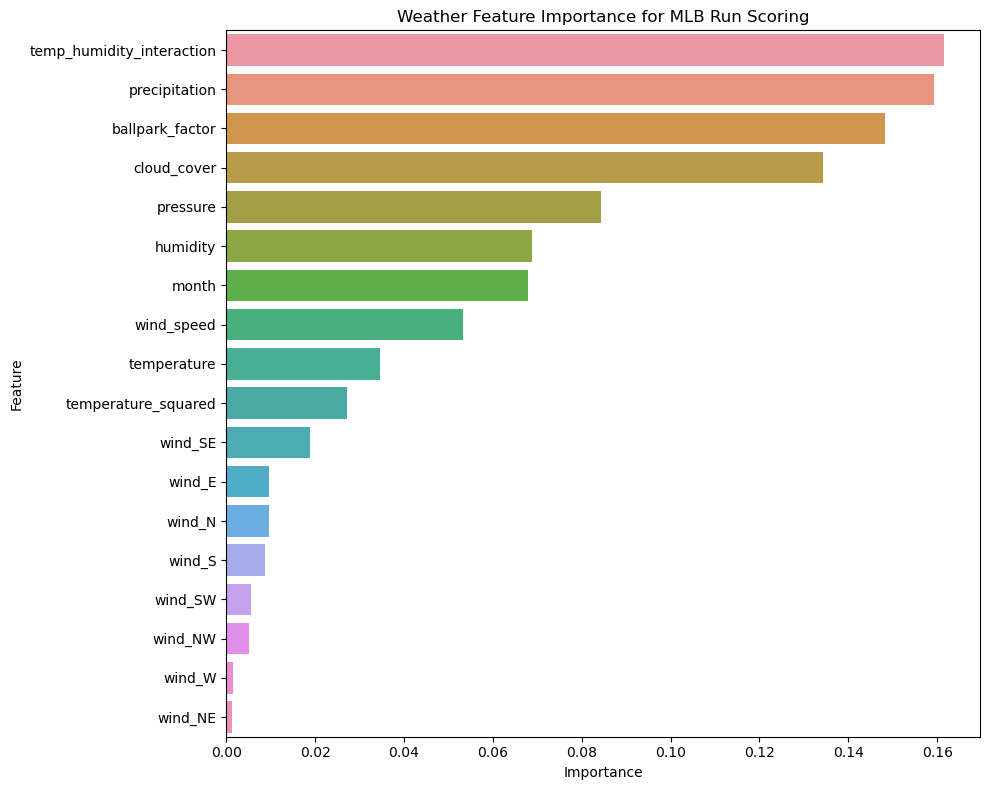

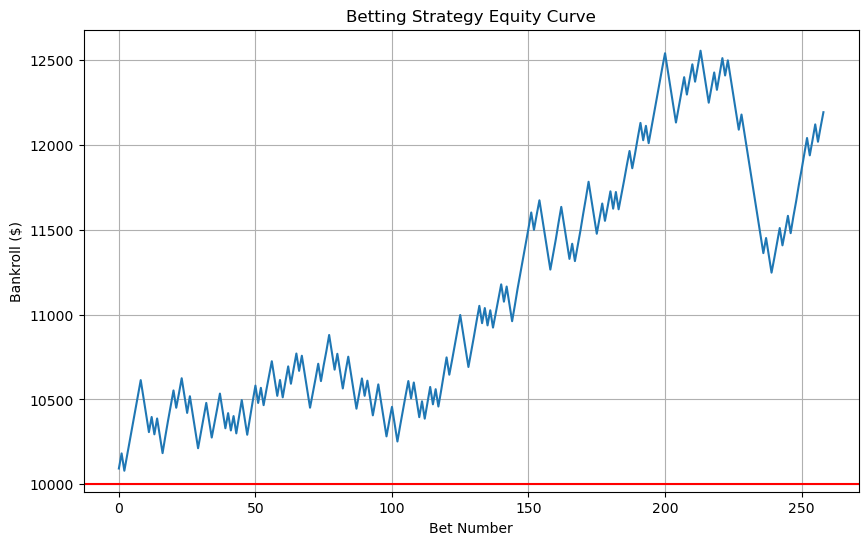

In [26]:
# Initialize the model
mlb_model = MLBWeatherModel()

# Test if it works
print("Model initialized successfully!")

# Start with a limited recent season for testing
print("\nFetching real MLB game data...")
mlb_model.fetch_game_data(2022, 2022)

# Get weather data
print("\nFetching weather data...")
mlb_model.fetch_weather_data()

# Generate betting odds with the correct API key
print("\nFetching betting odds...")
mlb_model.fetch_odds_data()

# Merge all data
print("\nMerging data...")
mlb_model.merge_data()

# Train and evaluate the model
print("\nTraining model...")
mlb_model.train_model()

# Analyze feature importance
print("\nAnalyzing feature importance...")
importance = mlb_model.analyze_feature_importance()
print(importance.head(10))

# Find betting opportunities
print("\nFinding betting opportunities...")
opportunities = mlb_model.find_betting_opportunities(confidence_threshold=0.75)

# Run backtest
print("\nRunning backtest...")
results = mlb_model.backtest_strategy(kelly=False)

Sample of identified betting opportunities:


,date,home_team,away_team,over_under_line,predicted_runs,recommended_bet,bet_correct,source
2357,2022-09-02,NYM,WSH,17.0,18.002574,OVER,1,synthetic
2366,2022-09-03,PIT,TOR,18.5,17.660351,UNDER,1,synthetic
2371,2022-09-03,LAD,SD,17.0,15.644231,UNDER,1,synthetic
2361,2022-09-03,AZ,MIL,18.0,16.354206,UNDER,0,synthetic
2364,2022-09-03,TB,NYY,18.5,17.590885,UNDER,1,synthetic
2392,2022-09-04,ATL,MIA,18.5,16.567844,UNDER,1,synthetic
2390,2022-09-04,STL,CHC,17.0,18.054790,OVER,0,synthetic
2385,2022-09-04,LAA,HOU,17.5,16.649723,UNDER,1,synthetic
2393,2022-09-04,LAD,SD,18.0,15.883893,UNDER,0,synthetic
2383,2022-09-04,CLE,SEA,18.0,16.940727,UNDER,0,synthetic



Over bets: 100, Win rate: 0.4600
Under bets: 159, Win rate: 0.6478
Synthetic odds bets: 259, Win rate: 0.5753


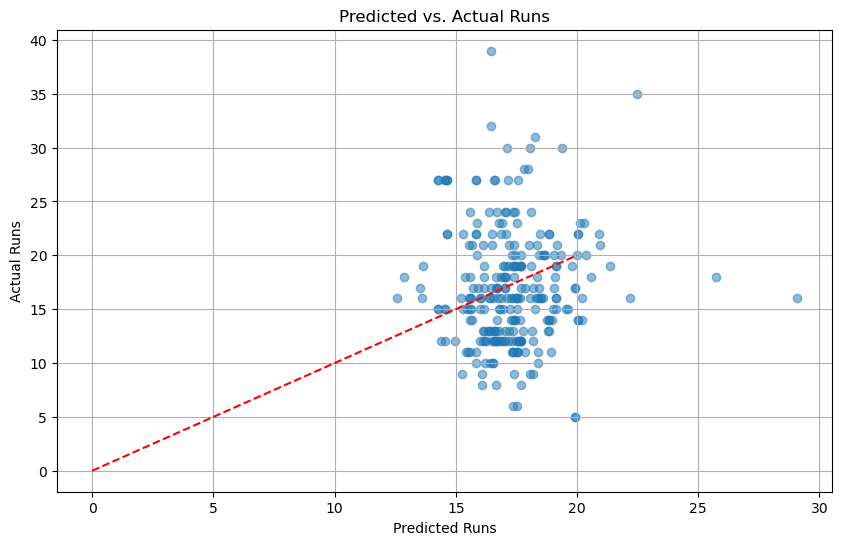

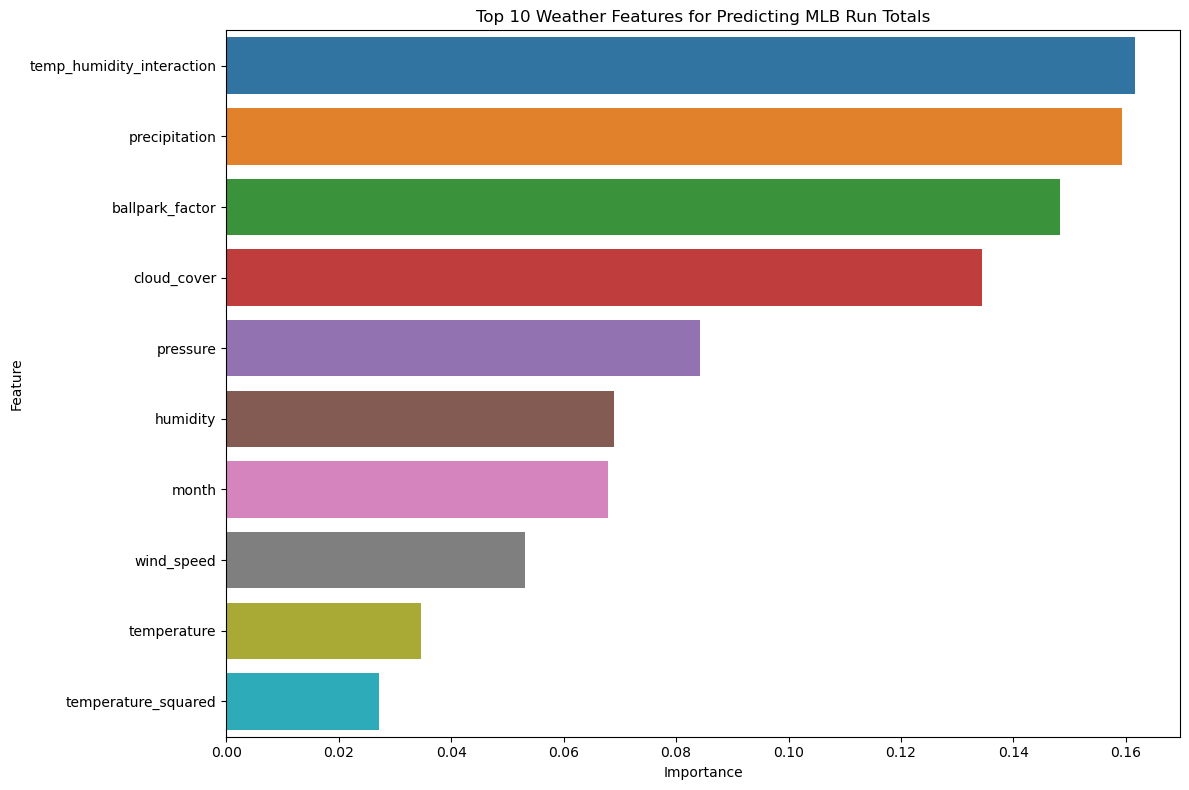

In [27]:
# Display betting opportunities
if opportunities is not None and len(opportunities) > 0:
    print("Sample of identified betting opportunities:")
    display(opportunities[['date', 'home_team', 'away_team', 'over_under_line', 
                         'predicted_runs', 'recommended_bet', 'bet_correct', 'source']].head(10))
    
    # Success rate by bet type
    over_bets = opportunities[opportunities['recommended_bet'] == 'OVER']
    under_bets = opportunities[opportunities['recommended_bet'] == 'UNDER']
    
    print(f"\nOver bets: {len(over_bets)}, Win rate: {over_bets['bet_correct'].mean():.4f}")
    print(f"Under bets: {len(under_bets)}, Win rate: {under_bets['bet_correct'].mean():.4f}")
    
    # Success rate by odds source (real vs synthetic)
    if 'source' in opportunities.columns:
        real_odds = opportunities[opportunities['source'] == 'real_odds_api']
        synth_odds = opportunities[opportunities['source'] == 'synthetic']
        
        if len(real_odds) > 0:
            print(f"\nReal odds bets: {len(real_odds)}, Win rate: {real_odds['bet_correct'].mean():.4f}")
        if len(synth_odds) > 0:
            print(f"Synthetic odds bets: {len(synth_odds)}, Win rate: {synth_odds['bet_correct'].mean():.4f}")
    
    # Plot distribution of predicted runs vs. actual runs
    plt.figure(figsize=(10, 6))
    plt.scatter(opportunities['predicted_runs'], opportunities['total_runs'], alpha=0.5)
    plt.plot([0, 20], [0, 20], 'r--')  # Perfect prediction line
    plt.title('Predicted vs. Actual Runs')
    plt.xlabel('Predicted Runs')
    plt.ylabel('Actual Runs')
    plt.grid(True)
    plt.show()
    
    # Feature importance visualization
    if importance is not None:
        plt.figure(figsize=(12, 8))
        top_features = importance.head(10)
        sns.barplot(x='Importance', y='Feature', data=top_features)
        plt.title('Top 10 Weather Features for Predicting MLB Run Totals')
        plt.tight_layout()
        plt.show()
else:
    print("No betting opportunities found with current threshold.")

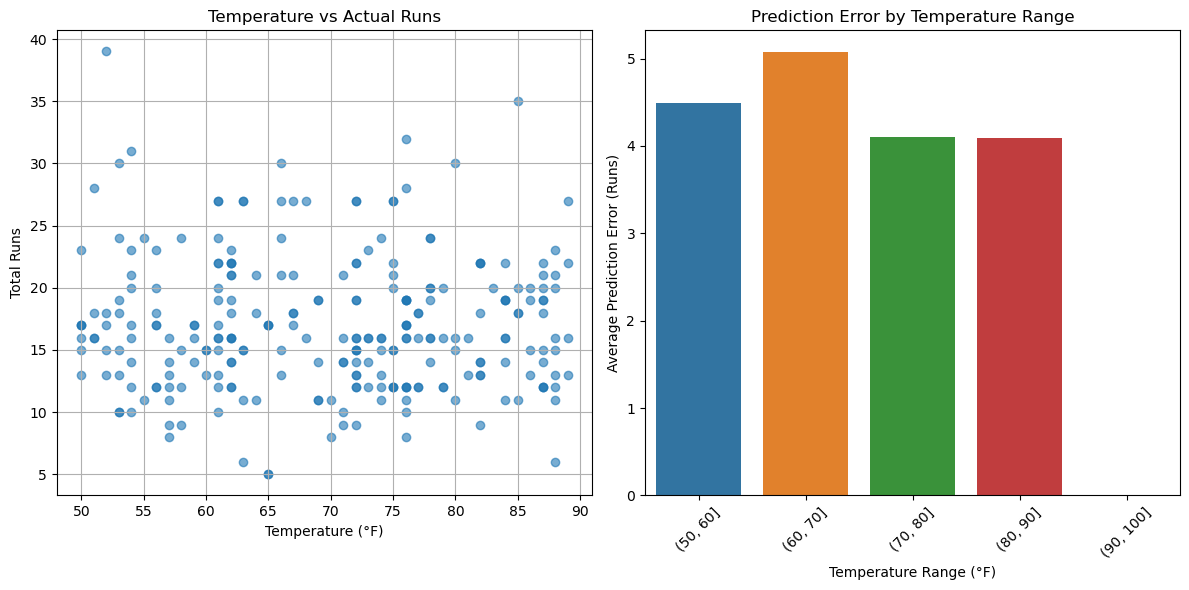

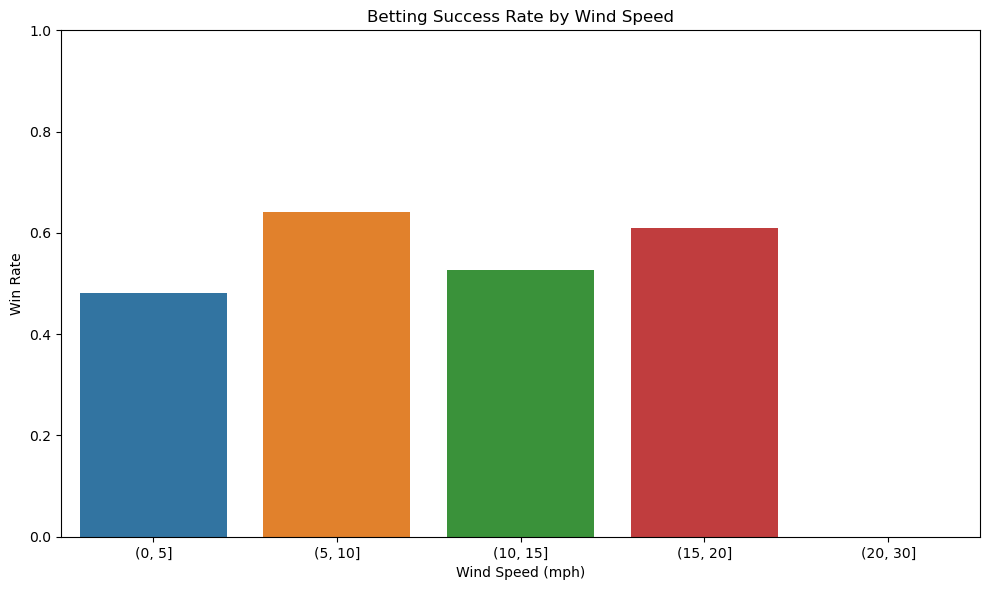

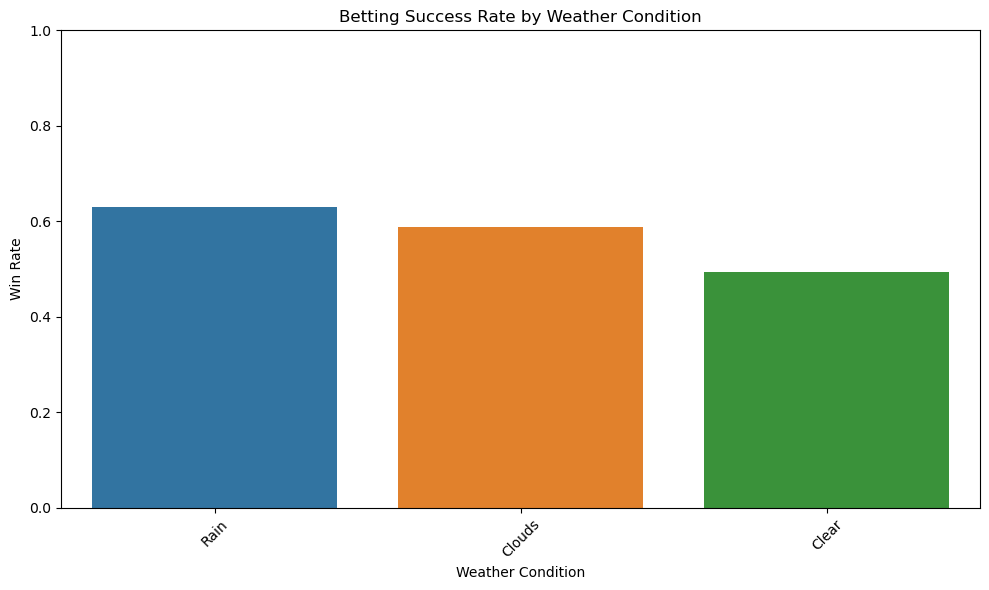

In [28]:
# Deeper analysis of weather conditions impact on model performance
if opportunities is not None and len(opportunities) > 0:
    
    # Analyze temperature impact
    plt.figure(figsize=(12, 6))
    
    # Temperature vs Run Scoring
    plt.subplot(1, 2, 1)
    plt.scatter(opportunities['temperature'], opportunities['total_runs'], alpha=0.6)
    plt.title('Temperature vs Actual Runs')
    plt.xlabel('Temperature (°F)')
    plt.ylabel('Total Runs')
    plt.grid(True)
    
    # Temperature vs Prediction Accuracy
    plt.subplot(1, 2, 2)
    # Calculate prediction error
    opportunities['pred_error'] = abs(opportunities['predicted_runs'] - opportunities['total_runs'])
    
    # Bin temperature into ranges
    temp_bins = [50, 60, 70, 80, 90, 100]
    opportunities['temp_bin'] = pd.cut(opportunities['temperature'], temp_bins)
    
    # Calculate average error by temperature bin
    error_by_temp = opportunities.groupby('temp_bin')['pred_error'].mean().reset_index()
    
    # Plot
    sns.barplot(x='temp_bin', y='pred_error', data=error_by_temp)
    plt.title('Prediction Error by Temperature Range')
    plt.xlabel('Temperature Range (°F)')
    plt.ylabel('Average Prediction Error (Runs)')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Wind conditions impact
    if 'wind_speed' in opportunities.columns:
        plt.figure(figsize=(10, 6))
        wind_bins = [0, 5, 10, 15, 20, 30]
        opportunities['wind_bin'] = pd.cut(opportunities['wind_speed'], wind_bins)
        win_rate_by_wind = opportunities.groupby('wind_bin')['bet_correct'].mean().reset_index()
        
        sns.barplot(x='wind_bin', y='bet_correct', data=win_rate_by_wind)
        plt.title('Betting Success Rate by Wind Speed')
        plt.xlabel('Wind Speed (mph)')
        plt.ylabel('Win Rate')
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.show()
    
    # Weather condition impact
    if 'weather_condition' in opportunities.columns:
        plt.figure(figsize=(10, 6))
        condition_counts = opportunities['weather_condition'].value_counts()
        weather_to_include = condition_counts[condition_counts >= 5].index.tolist()
        
        weather_impact = opportunities[opportunities['weather_condition'].isin(weather_to_include)]
        if len(weather_impact) > 0:
            weather_success = weather_impact.groupby('weather_condition')['bet_correct'].mean().reset_index()
            weather_success = weather_success.sort_values('bet_correct', ascending=False)
            
            sns.barplot(x='weather_condition', y='bet_correct', data=weather_success)
            plt.title('Betting Success Rate by Weather Condition')
            plt.xlabel('Weather Condition')
            plt.ylabel('Win Rate')
            plt.ylim(0, 1)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

In [14]:
pip install nbconvert[webpdf]

zsh:1: no matches found: nbconvert[webpdf]
Note: you may need to restart the kernel to use updated packages.
